# IMporting libraries and files

In [185]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [186]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp
import xplt


import crystal_extraction.plotters as plotters
import crystal_extraction.utils as utils
from crystal_extraction.xsuite_line_creation import create_xsuite_line
#from crystal_extraction.crystal_extraction import CrystalExtraction
from crystal_extraction.dummy_crystal import DummyCrystal
from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

plotters.my_mpl_style()


In [187]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools
from shapely.geometry import Polygon
import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')

from elements import *
from optimesers import *


# Importing the sequence


In [188]:
from elements import install_septa
line = xt.Line.from_json("../database/lhc_q22.json")


# REFERENCE PARTICLE
line.particle_ref = xt.Particles(p0c=400e9, mass0=xt.PROTON_MASS_EV)

# INSERTING MARKERS
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)
line.insert_element("tpst.21760_entry", xt.Marker(), at_s = 1712.2203)
line.insert_element("TECA.entry", xt.Marker(), at_s = 4020.8939)
#line.insert_element("TECS.everest_crystal", TECS, at_s = line.get_table()['s', 'tecs.21602'] )

line.insert_element("tcsm.51932.", xt.Marker(), at_s = 5219.6766)

teca_entry_s = line.get_table()['s', 'TECA.entry']

line.cycle("TECA.entry", inplace=True)


Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

<Line  at 5339864336>

In [189]:
# Get the positions of the TECA and COLLIMATORS markers
teca_position = line.get_table()['s', 'TECA.entry']
tpst_position = line.get_table()['s', 'tpst.21760_entry']
tcsm_position = line.get_table()['s', 'tcsm.51932.']

In [190]:
print_optics_features(line)

22.13000000010263
22.180000000010537
D term / B term = 3.31
sigma_x max = 10.468444863433009 mm
sigma_y max = 1.1036200168346404 mm
D term / B term = 3.31
sigma_x max = 0.010468444863433008 m
sigma_y max = 0.0011036200168346405 m
Phase advance Teca - Tpst: 14.74
Phase advance Teca - Tcsm: 3.83
Phase advance Tpst - Tcsm: -10.91


## Matching the tunes

In [191]:
tune = 22.91

In [192]:
optTune = match_tunes(line, tune, tune + 0.05)
optChromaticity = match_chromaticity(line, tune, tune + 0.05)

optTune.step(10)
optTune.target_status()
optTune.vary_status()

# CHanging the chromaticity afterwards
optChromaticity.step(10)

optChromaticity.target_status()
optChromaticity.vary_status() 

line.discard_tracker()


                                             
Optimize - start penalty: 11.03         
Matching: model call n. 13               
Optimize - end penalty:  1.00086e-05
Target status:                           
id state tag tol_met       residue   current_val    target_val description                          
0  ON    qx     True   5.26803e-07         22.91         22.91 'qx', val=22.91, tol=1e-05, weight=10
1  ON    qy     True   8.51001e-07         22.96         22.96 'qy', val=22.96, tol=1e-05, weight=10
Vary status:                 
id state tag met name         lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqf          None            0.0129521 None            0.0125751         1e-07             1
1  ON        OK  kqd          None            -0.012955 None           -0.0125777         1e-07             1
2  ON        OK  qph_setvalue None          3.90187e-14 None                    0        0.0001             1
3  ON        OK  qp

In [193]:
tw = line.twiss(method='4d')

tw_df = tw.to_pandas()
tw_df.set_index('name', inplace=True)
tw_df = tw_df.loc['mdha.21606':'drift_mdva.21932..1'] 
tw_df = tw_df.drop_duplicates(subset='s')



# Find apertures tha block the particles and open them

In [194]:
blocking_elements = open_blocking_apertures(line, TECA, deltaP_P)

The line already has an associated tracker
Non-channeled particle lost at element ap.up.tpsg41832_aper (index 14) on turn 0
Adjusting ap.up.tpsg41832_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.tpsg41832_aper (index 17) on turn 0
Adjusting ap.do.tpsg41832_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mse41837_aper (index 20) on turn 0
Adjusting ap.up.mse41837_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mse41837_aper (index 25) on turn 0
Adjusting ap.do.mse41837_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mse41852_aper (index 28) on turn 0
Adjusting ap.up.mse41852_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled part

In [195]:
remove_ZS_apertures(line)

Opening aperture for element: ap.up.zs21633_aper
Element ap.up.zs21633 does not have adjustable apertures.
Element drift_zs.21633..1..0 does not have adjustable apertures.
Element zs21633.entry.p1mm does not have adjustable apertures.
Element drift_zs.21633..1..1 does not have adjustable apertures.
Element zs.21633 does not have adjustable apertures.
Element drift_zs.21633..2 does not have adjustable apertures.
Opening aperture for element: ap.do.zs21633_aper
Element ap.do.zs21633 does not have adjustable apertures.
Element drift_zs.21639..1 does not have adjustable apertures.
Element zs.21639 does not have adjustable apertures.
Element drift_zs.21639..2 does not have adjustable apertures.
Opening aperture for element: ap.up.zs21655_aper
Element ap.up.zs21655 does not have adjustable apertures.
Element drift_zs.21655..1 does not have adjustable apertures.
Element zs.21655 does not have adjustable apertures.
Element drift_zs.21655..2 does not have adjustable apertures.
Opening aperture 

In [196]:
save_df_Limit_elements_features(line)

      Position         Element Name    max_x    min_x
0    3336.5340        qe.11402_aper  0.07600 -0.07600
1    3434.5709        qd.11710_aper  0.04150 -0.04150
2    3438.9739      mdhw.11732_aper  0.07600 -0.07600
3    3442.7352      mdhw.11737_aper  0.07600 -0.07600
4    3443.7942      mdhw.11738_aper  0.07600 -0.07600
..         ...                  ...      ...      ...
102  2328.2393  ap.do.mse61852_aper  0.06582 -0.06582
103  2329.0933  ap.up.mse61857_aper  0.06850 -0.06850
104  2331.4733  ap.do.mse61857_aper  0.07635 -0.07635
105  2332.3273  ap.up.mse61872_aper  0.08024 -0.08024
106  2334.7073  ap.do.mse61872_aper  0.09100 -0.09100

[107 rows x 4 columns]


,Position,Element Name,max_x,min_x
0,3336.5340,qe.11402_aper,0.07600,-0.07600
1,3434.5709,qd.11710_aper,0.04150,-0.04150
2,3438.9739,mdhw.11732_aper,0.07600,-0.07600
3,3442.7352,mdhw.11737_aper,0.07600,-0.07600
4,3443.7942,mdhw.11738_aper,0.07600,-0.07600
...,...,...,...,...
102,2328.2393,ap.do.mse61852_aper,0.06582,-0.06582
103,2329.0933,ap.up.mse61857_aper,0.06850,-0.06850
104,2331.4733,ap.do.mse61857_aper,0.07635,-0.07635
105,2332.3273,ap.up.mse61872_aper,0.08024,-0.08024


# Adjust the bump at the extraction point

In [197]:
# Switch on extraction bump
line.vv["extr_bump_knob"] = 0.88


In [198]:
# Save the line with the current optics into a JSON file
line.to_json("../database/lhc_q23.json")

In [199]:
import matplotlib.pyplot as plt
import numpy as np
import xtrack as xt

#line.insert_element("TECS.everest_crystal", TECS, at_s=line.get_table()['s', 'tecs.21602'])
line.build_tracker()

# Initialize a single particle at TECA location
particlesNONCH = line.build_particles(
    method='4d',
    x=TECA.jaw,
    px=TECA.tilt,  # THE BENDING ANGLE INDICATES THAT THE PARTICLE IS CHANNELED
    y=0,
    py=0,
    zeta=0,
    delta=deltaP_P,
    mass0=xt.PROTON_MASS_EV,
    p0c=400e9
)

# Track particles for N turns and store positions
line.track(particlesNONCH, num_turns=1, turn_by_turn_monitor="ONE_TURN_EBE",)
recordNONCH = line.record_last_track


# Check if the particle is lost during the tracking
if np.any(recordNONCH.state < 1):
    lost_turn = np.where(recordNONCH.state < 1)[0][0]
    lost_element_index = recordNONCH.at_element[lost_turn]
    lost_element_name = line.element_names[lost_element_index]
    print(f"Particle lost at element {lost_element_name} (index {lost_element_index}) on turn {lost_turn}")
        
else:
    print("Particle not lost during the tracking")

The line already has an associated tracker
Particle not lost during the tracking


# Installing the septa to extract the particles

In [200]:
line.discard_tracker()
septa_names_with_apertures = install_septa(line, install_zs=False)

In [201]:
print(septa_names_with_apertures)

['tpst.21760_entry.sep', 'mst.21774.sep', 'mst.21779.sep', 'mst.21794.sep', 'mse.21832.sep', 'mse.21837.sep', 'mse.21852.sep', 'mse.21857.sep', 'mse.21872.sep']


In [202]:
df_elements = save_df_Limit_elements_features(line)

      Position         Element Name    max_x    min_x
0    3336.5340        qe.11402_aper  0.07600 -0.07600
1    3434.5709        qd.11710_aper  0.04150 -0.04150
2    3438.9739      mdhw.11732_aper  0.07600 -0.07600
3    3442.7352      mdhw.11737_aper  0.07600 -0.07600
4    3443.7942      mdhw.11738_aper  0.07600 -0.07600
..         ...                  ...      ...      ...
103  2329.0933  ap.up.mse61857_aper  0.06850 -0.06850
104  2331.4733  ap.do.mse61857_aper  0.07635 -0.07635
105  2332.3273  ap.up.mse61872_aper  0.08024 -0.08024
106  2334.7073  ap.do.mse61872_aper  0.09100 -0.09100
107  4638.5419      tt20.extraction  0.07000 -1.00000

[108 rows x 4 columns]


In [203]:
save_horizontal_positions_at_septa(recordNONCH, line, septa_names_with_apertures)

                Element  X Position
0  tpst.21760_entry.sep   -0.004456
1         mst.21774.sep   -0.000819
2         mst.21779.sep    0.003073
3         mst.21794.sep    0.005919
4         mse.21832.sep    0.013284
5         mse.21837.sep    0.015171
6         mse.21852.sep    0.016663
7         mse.21857.sep    0.018156
8         mse.21872.sep    0.020836


In [204]:
line.build_tracker()
# Initialize a single particle at TECA location
particlesCH = line.build_particles(
    method='4d',
    x=TECA.jaw,
    px=TECA.tilt + TECA.bending_angle,  # THE BENDING ANGLE INDICATES THAT THE PARTICLE IS CHANNELED
    y=0,
    py=0,
    zeta=0,
    delta=deltaP_P,
    mass0=xt.PROTON_MASS_EV,
    p0c=400e9
)

# Track particles for N turns and store positions
line.track(particlesCH, num_turns=1, turn_by_turn_monitor="ONE_TURN_EBE",)
recordCH = line.record_last_track

# Check if the particle is lost during the tracking
if np.any(particlesCH.state < 1):
    lost_turn = np.where(particlesCH.state < 1)[0][0]
    lost_element_index = particlesCH.at_element[lost_turn]
    lost_element_name = line.element_names[lost_element_index]
    print(f"Particle lost at element {lost_element_name} (index {lost_element_index}) on turn {lost_turn}")
else:
    print("Particle not lost during the tracking")

Particle not lost during the tracking


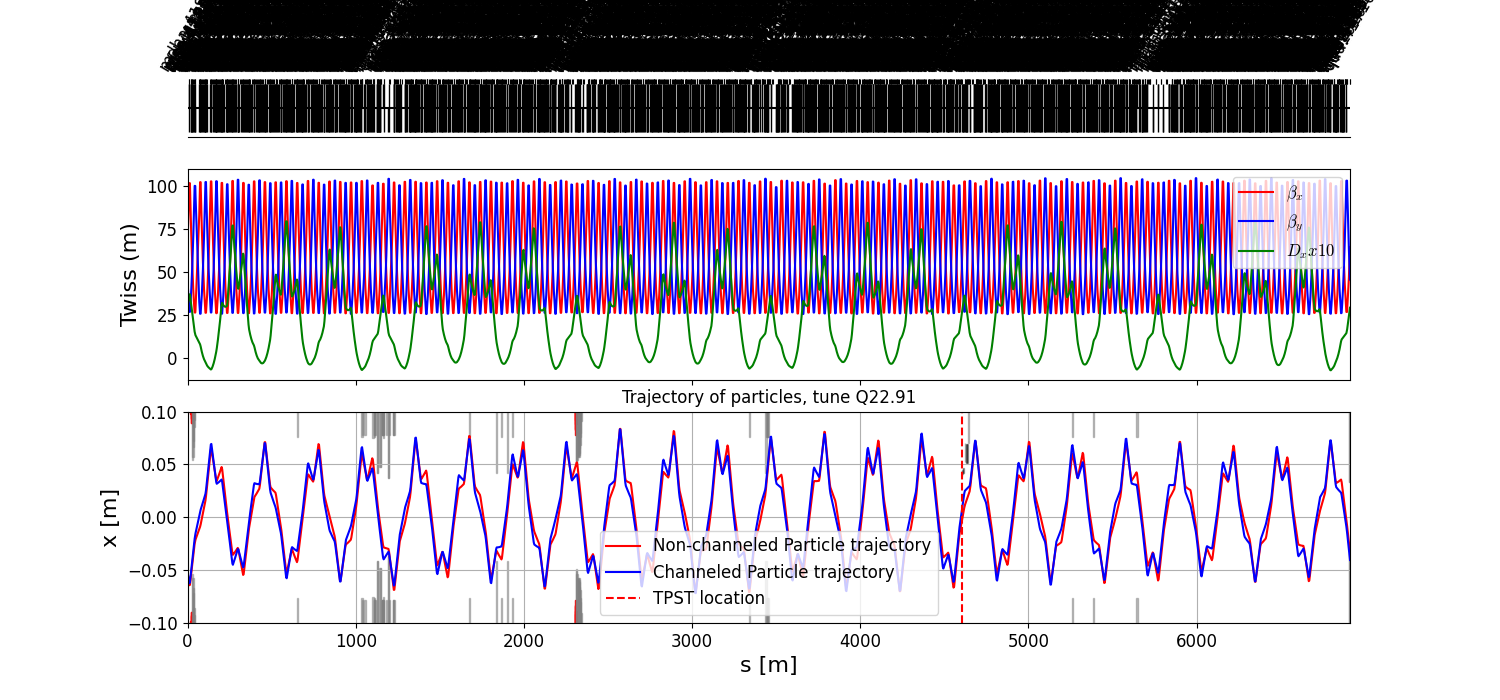

In [205]:
from functions import plot_twiss

fig = plt.figure(figsize=(15,7))

plot_twiss(fig, tw, line)

fig.axes[2].grid(True)

fig.axes[2].plot(recordNONCH.s[0], recordNONCH.x[0], '-', color='red', label='Non-channeled Particle trajectory')
fig.axes[2].plot(recordCH.s[0], recordCH.x[0], '-', color='blue', label='Channeled Particle trajectory')
fig.axes[2].set_xlabel('s [m]')
fig.axes[2].set_ylabel('x [m]')
fig.axes[2].set_title(f'Trajectory of particles, tune Q{tune}')
fig.axes[2].grid(True)

fig.axes[2].set_ylim(-0.1, 0.1)
#fig.axes[2].set_xlim(4590, 4650)

for element_name in septa_names_with_apertures:
    x = line[element_name].interaction_process.blade_position
    thickness = line[element_name].interaction_process.thickness
    s = line.get_table()['s', element_name]
    fig.axes[2].add_patch(mpl.patches.Rectangle((s, x), 1, thickness, color='k', alpha=0.3))
    

# Insert rectangles for each element in df_elements
for _, row in df_elements.iterrows():
    color = 'grey'
    alpha = 0.5
    if row['Element Name'] in [elem[0] for elem in blocking_elements]:
        color = 'red'
        alpha = 1.0
    # Rectangle from min_x to bottom
    rect_min = plt.Rectangle((row['Position'], -0.25), width=8, height=row['min_x'] + 0.25, color=color, alpha=alpha)
    fig.axes[2].add_patch(rect_min)
    
    # Rectangle from max_x to top
    rect_max = plt.Rectangle((row['Position'], row['max_x']), width=8, height=0.25 - row['max_x'], color=color, alpha=alpha)
    fig.axes[2].add_patch(rect_max)

fig.axes[2].axvline(x=tpst_position, color='r', linestyle='--', label='TPST location')
fig.axes[2].legend()

#